In [60]:
!pip install transformers

In [61]:
# from google.colab import drive
# drive.mount('/content/drive')

In [62]:
#@title import packages

import torch
import numpy as np
import pandas as pd
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import KMeans

import torch.nn as nn

from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Normalize, Resize, Compose, ToPILImage

In [63]:
#@title Plotting functions

import argparse
import torch
import matplotlib.pyplot as plt
import torchvision.transforms
from torch import nn
from torchvision import transforms
import torch.nn.modules.utils as nn_utils
import math
#import timm
import types
from pathlib import Path
from typing import Union, List, Tuple
from PIL import Image
from matplotlib.colors import ListedColormap

def imsc(img, *args, quiet=False, lim=None, interpolation='lanczos', **kwargs):
    r"""Rescale and displays an image represented as a img.
    The function scales the img :attr:`im` to the [0 ,1] range.
    The img is assumed to have shape :math:`3\times H\times W` (RGB)
    :math:`1\times H\times W` (grayscale).
    Args:
        img (:class:`torch.Tensor` or :class:`PIL.Image`): image.
        quiet (bool, optional): if False, do not display image.
            Default: ``False``.
        lim (list, optional): maximum and minimum intensity value for
            rescaling. Default: ``None``.
        interpolation (str, optional): The interpolation mode to use with
            :func:`matplotlib.pyplot.imshow` (e.g. ``'lanczos'`` or
            ``'nearest'``). Default: ``'lanczos'``.
    Returns:
        :class:`torch.Tensor`: Rescaled image img.
    """
    if isinstance(img, Image.Image):
        img = pil_to_tensor(img)
    handle = None
    with torch.no_grad():
        if not lim:
            lim = [img.min(), img.max()]
        img = img - lim[0]  # also makes a copy
        img.mul_(1 / (lim[1] - lim[0]))
        img = torch.clamp(img, min=0, max=1)
        if not quiet:
            bitmap = img.expand(3,
                                *img.shape[1:]).permute(1, 2, 0).cpu().numpy()
    return bitmap

def draw_correspondences(points1: List[Tuple[float, float]], points2: List[Tuple[float, float]],
                         image1: Image.Image, image2: Image.Image) -> Tuple[plt.Figure, plt.Figure]:
    """
    draw point correspondences on images.
    :param points1: a list of (y, x) coordinates of image1, corresponding to points2.
    :param points2: a list of (y, x) coordinates of image2, corresponding to points1.
    :param image1: a PIL image.
    :param image2: a PIL image.
    :return: two figures of images with marked points.
    """
    assert len(points1) == len(points2), f"points lengths are incompatible: {len(points1)} != {len(points2)}."
    num_points = len(points1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
    ax1.axis('off')
    ax2.axis('off')
    #ax1.imshow(image1)
    #ax2.imshow(image2)
    ax1.imshow(imsc(image1))
    ax2.imshow(imsc(image2))

    if not points1:
      return fig

    if num_points > 15:
        cmap = plt.get_cmap('tab10')
    else:
        cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
                               "maroon", "black", "white", "chocolate", "gray", "blueviolet"])
    colors = np.array([cmap(x) for x in range(num_points)])
    radius1, radius2 = 8, 1
    for point1, point2, color in zip(points1, points2, colors):
        y1, x1 = point1
        circ1_1 = plt.Circle((x1, y1), radius1, facecolor=color, edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x1, y1), radius2, facecolor=color, edgecolor='white')
        ax1.add_patch(circ1_1)
        ax1.add_patch(circ1_2)
        y2, x2 = point2
        circ2_1 = plt.Circle((x2, y2), radius1, facecolor=color, edgecolor='white', alpha=0.5)
        circ2_2 = plt.Circle((x2, y2), radius2, facecolor=color, edgecolor='white')
        ax2.add_patch(circ2_1)
        ax2.add_patch(circ2_2)
    return fig

In [64]:
#@title create dataset
from detectron2.data.detection_utils import read_image
from transformers import AutoImageProcessor

#processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch16")
#processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
#processor = AutoProcessor.from_pretrained("facebook/vit-mae-large")
#processor = AutoProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
#processor.do_center_crop = False

target_mean = [0.485, 0.456, 0.406]
target_std = [0.229, 0.224, 0.225]
processor = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(mean=target_mean, std=target_std)])

class CUB(Dataset):
    def __init__(self, base_path, train=True):

        self.base_path = base_path

        self.labels = pd.read_csv(''.join([base_path, 'image_class_labels.txt']), header=None, sep=" ", names=["id", "label"])
        self.train_test_split = pd.read_csv(''.join([base_path, 'train_test_split.txt']), header=None, sep=" ", names=["id", "is_train"])
        self.filenames = pd.read_csv(''.join([base_path, 'images.txt']), header=None, sep=" ")
        self.filenames = pd.read_csv(''.join([base_path, 'images.txt']), header=None, sep=" ")
        # self.segmentation_path = 'drive/MyDrive/CoSegXAI/datasets/cub200/segmentations/'
        self.segmentation_path = '/mnt/d/Github/SuperpixelCUB/CUB_200_data/segmentations/' # change folder path on your local machine

        self.transforms = Compose([
                ToTensor(),
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])

        if train:
          mask = self.train_test_split.is_train.values == 1
        else:
          mask = self.train_test_split.is_train.values == 0

        self.filenames = self.filenames.iloc[mask]
        self.labels = self.labels[mask]

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, index):

        y = self.labels.iloc[index, 1] - 1
        file_name = self.filenames.iloc[index, 1]

        x = Image.open(''.join([self.base_path, 'images/', file_name])).convert('RGB')
        x = processor(x)

        return x, y

data indices:  [5238, 2316]
data indices:  [5275, 2395, 5238, 2316]
[175, 79, 174, 77]


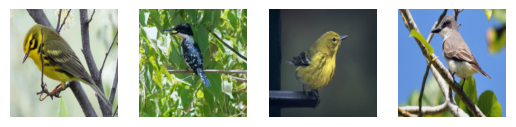

0 /mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/images/176.Prairie_Warbler/Prairie_Warbler_0086_172534.jpg
1 /mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/images/080.Green_Kingfisher/Green_Kingfisher_0037_71113.jpg
2 /mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/images/175.Pine_Warbler/Pine_Warbler_0010_171239.jpg
3 /mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/images/078.Gray_Kingbird/Gray_Kingbird_0045_70256.jpg


In [65]:
#@title dataset and dataloader and load samples

import random
from detectron2.data.detection_utils import read_image
query_transforms = Compose([
        torchvision.transforms.RandomHorizontalFlip(p=0.5),
        torchvision.transforms.RandomPerspective(distortion_scale=0.25, p=1.0),
        torchvision.transforms.RandomResizedCrop(size=224, scale=(0.5, 1.0)),
        ])

# base_path = 'drive/MyDrive/CoSegXAI/datasets/cub200/CUB_200_2011/CUB_200_2011/'
base_path = '/mnt/d/Github/SuperpixelCUB/CUB_200_data/CUB_200_2011/' # change folder path on your local machine

train_dataset = CUB(base_path)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
#file_names, x, y = next(iter(train_loader))

NUMBER_OF_PROTOTYPES = 2
# NUMBER_OF_PROTOTYPES = 1

random.seed(501)
# inputs, labels, masks = [], [], []
inputs, labels = [], []
#data_indices = []
data_indices = random.sample(range(train_dataset.__len__()), NUMBER_OF_PROTOTYPES)
print("data indices: ", data_indices)
data_indices.insert(0, 2395)
data_indices.insert(0, 5275)
# data_indices.insert(0, 1028)
# data_indices.insert(0, 5260)
# data_indices.insert(0, 912)
# data_indices.insert(0, 925)
# data_indices.insert(0, 2335)
# data_indices.insert(0, 5253)
# data_indices.insert(0, 5250)
# data_indices.insert(0, 1024)
# data_indices.insert(0, 1028)
#data_indices.insert(0, 16)
#data_indices = [153, 151, 213, 244]
print("data indices: ", data_indices)

for counter, data_idx in enumerate(data_indices):

  x, y = train_dataset.__getitem__(data_idx)

  #if counter == 0: x = query_transforms(x)

  inputs.append(x)
  labels.append(y)
  # masks.append(mask)

print(labels)

plt.figure(1)
plt.subplot(141)
plt.imshow(imsc(inputs[0]))
plt.axis('off')
plt.subplot(142)
plt.imshow(imsc(inputs[1]))
plt.axis('off')
plt.subplot(143)
plt.imshow(imsc(inputs[2]))
plt.axis('off')
plt.subplot(144)
plt.imshow(imsc(inputs[3]))
plt.axis('off')
plt.show()


# The image initializations in VLPart is different. We need to use read_image function
vlpart_inputs = []
file_inputs = []
for counter, data_idx in enumerate(data_indices):
    # print(counter,data_idx)
    vlpart_x = ''.join([base_path, 'images/', train_dataset.filenames.iloc[data_idx, 1]])
    image_path = ''.join([base_path, 'images/', train_dataset.filenames.iloc[data_idx, 1]])
    file_inputs.append(image_path)
    print(counter,vlpart_x)
    vlpart_x = read_image(''.join([base_path, 'images/', train_dataset.filenames.iloc[data_idx, 1]]), format="BGR")
    vlpart_inputs.append(vlpart_x)

In [66]:
#@title load model


from transformers import AutoProcessor, CLIPVisionModel, Dinov2Model, ViTMAEModel, ViTModel

#model = CLIPVisionModel.from_pretrained("openai/clip-vit-large-patch14").to('cuda')
model = Dinov2Model.from_pretrained("facebook/dinov2-base").to('cuda')
#model = ViTMAEModel.from_pretrained("facebook/vit-mae-large", attn_implementation="eager").to('cuda')
#model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k", attn_implementation="eager").to('cuda')


In [67]:
#@title create patch embeddings

IMG_SIZE = x.shape[-1]
print("image size:", IMG_SIZE)

device='cuda'

embedings = []
heatmaps = []

#embedings.append(model.encoder(model.get_input_embeddings()(input_i)).last_hidden_state[0, :, :].numpy(force=True)) MAE thing

with torch.no_grad():

    for counter, input_i in enumerate(inputs):

        input_i = input_i.to(device).unsqueeze(0)

        outputs = model(input_i, output_attentions=True)

        #embedings.append(model.visual_projection(outputs.last_hidden_state[0, 1:, :]).numpy(force=True))
        embedings.append(outputs.last_hidden_state[0, 1:, :].numpy(force=True))

        heatmaps.append(outputs.attentions[0].mean(1)[:, 0, 1:].numpy(force=True))

NUMBER_OF_PATCHES = outputs.last_hidden_state[0, 1:, :].shape[0]
SQRT_NUMBER_OF_PATCHES = int(np.sqrt(NUMBER_OF_PATCHES))
STRIDE = model.config.patch_size #model.get_submodule('embeddings').get_submodule('patch_embeddings').get_submodule('projection').stride[0]
PATCH_SIZE = model.config.patch_size
print("patch size:", PATCH_SIZE)
NUMBER_OF_PATCHES_X = NUMBER_OF_PATCHES_Y = int(IMG_SIZE / PATCH_SIZE)
print("number of patches:", NUMBER_OF_PATCHES)
print("number of patches x:", NUMBER_OF_PATCHES_X)
print("number of patches y:", NUMBER_OF_PATCHES_Y)
LATENT_DIM = embedings[0].shape[-1]

image size: 224
patch size: 14
number of patches: 256
number of patches x: 16
number of patches y: 16


In [68]:
import glob
import multiprocessing as mp
import numpy as np
import os
import tempfile
import time
import warnings
import cv2
import tqdm
import argparse

from detectron2.config import get_cfg
from detectron2.data.detection_utils import read_image
from detectron2.utils.logger import setup_logger
import sys
from VLPart.vlpart.config import add_vlpart_config
from VLPart.demo.predictor import VisualizationDemo
from detectron2.config import CfgNode

DEFAULT_CONFIG_FILE = "/mnt/d/Github/SuperpixelCUB/VLPart/configs/pascal_part/r50_pascalpart.yaml"
DEFAULT_WEIGHTS = "/mnt/d/Github/SuperpixelCUB/VLPart/checkpoints/r50_pascalpart.pth"
DEFAULT_CONFIDENCE_THRESHOLD = 0.7
# CUSTOM_VOCABULARY =  ["bird beak", "bird head", "bird eye","bird leg", "bird foot", "bird wing", "bird neck", "bird tail","bird torso" ]
# CUSTOM_VOCABULARY = ["bird:back", "bird:head", "bird:foot", "bird:neck", "bird:beak", "bird:belly", "bird:breast", "bird:crown", "bird:eye", "bird:wing", "bird:nape", "bird:leg", "bird:torso", "bird:tail"]
CUSTOM_VOCABULARY = "bird back, bird head, bird foot, bird neck, bird beak, bird belly, bird breast, bird crown, bird eye, bird wing, bird nape, bird leg, bird torso, bird tail"
DEFAULT_OUTPUT_PATH = "/mnt/d/Github/SuperpixelCUB/output/"

def get_parser():
    parser = argparse.ArgumentParser(description="Detectron2 demo for builtin configs")
    parser.add_argument(
        "--config-file",
        default="configs/quick_schedules/mask_rcnn_R_50_FPN_inference_acc_test.yaml",
        metavar="FILE",
        help="path to config file",
    )
    parser.add_argument("--webcam", action="store_true", help="Take inputs from webcam.")
    parser.add_argument("--video-input", help="Path to video file.")
    parser.add_argument(
        "--input",
        nargs="+",
        help="A list of space separated input images; "
        "or a single glob pattern such as 'directory/*.jpg'",
    )
    parser.add_argument(
        "--output",
        help="A file or directory to save output visualizations. "
        "If not given, will show output in an OpenCV window.",
    )
    parser.add_argument(
        "--vocabulary",
        default="pascal_part",
        choices=['pascal_part', 'partimagenet', 'paco',
                 'voc', 'coco', 'lvis',
                 'pascal_part_voc', 'lvis_paco', 'custom'],
        help="",
    )
    parser.add_argument(
        "--custom_vocabulary",
        default="",
        help="",
    )
    parser.add_argument(
        "--confidence-threshold",
        type=float,
        default=0.5,
        help="Minimum score for instance predictions to be shown",
    )

    parser.add_argument(
        "--opts",
        help="Modify config options using the command-line 'KEY VALUE' pairs",
        default=[],
        nargs=argparse.REMAINDER,
    )
    return parser


def setup_cfg(args):
    # load config from file and command-line arguments
    cfg = get_cfg()
    add_vlpart_config(cfg)
    cfg.merge_from_file(args.config_file)
    cfg.MODEL.WEIGHTS = DEFAULT_WEIGHTS
    cfg.merge_from_list(['VIS.BOX', 'False'])
    # cfg.merge_from_list(args.opts)
    # Set score_threshold for builtin models
    cfg.MODEL.RETINANET.SCORE_THRESH_TEST = DEFAULT_CONFIDENCE_THRESHOLD
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = DEFAULT_CONFIDENCE_THRESHOLD
    cfg.MODEL.PANOPTIC_FPN.COMBINE.INSTANCES_CONFIDENCE_THRESH = DEFAULT_CONFIDENCE_THRESHOLD
    cfg.freeze()
    return cfg

mp.set_start_method("spawn", force=True)
args = get_parser().parse_args([])
args.config_file = DEFAULT_CONFIG_FILE
# args.custom_vocabulary = CUSTOM_VOCABULARY
# args.vocabulary = "custom"
args.confidence_threshold  = DEFAULT_CONFIDENCE_THRESHOLD
setup_logger(name="fvcore")
logger = setup_logger()
logger.info("Arguments: " + str(args))
cfg = setup_cfg(args)


[08/02 17:37:12 detectron2]: Arguments: Namespace(config_file='/mnt/d/Github/SuperpixelCUB/VLPart/configs/pascal_part/r50_pascalpart.yaml', webcam=False, video_input=None, input=None, output=None, vocabulary='pascal_part', custom_vocabulary='', confidence_threshold=0.7, opts=[])


In [69]:
from dataclasses import dataclass
from typing import Any, List, Dict, Optional, Union, Tuple
@dataclass
class BoundingBox:
    xmin: int
    ymin: int
    xmax: int
    ymax: int

    @property
    def xyxy(self) -> List[float]:
        return [self.xmin, self.ymin, self.xmax, self.ymax]

@dataclass
class DetectionResult:
    score: float
    label: str
    box: BoundingBox
    mask: Optional[np.array] = None

    @classmethod
    def from_dict(cls, detection_dict: Dict) -> 'DetectionResult':
        return cls(score=detection_dict['score'],
                   label=detection_dict['label'],
                   box=BoundingBox(xmin=detection_dict['box']['xmin'],
                                   ymin=detection_dict['box']['ymin'],
                                   xmax=detection_dict['box']['xmax'],
                                   ymax=detection_dict['box']['ymax']))

In [70]:
import requests


def mask_to_polygon(mask: np.ndarray) -> List[List[int]]:
    # Find contours in the binary mask
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Find the contour with the largest area
    largest_contour = max(contours, key=cv2.contourArea)

    # Extract the vertices of the contour
    polygon = largest_contour.reshape(-1, 2).tolist()

    return polygon

def polygon_to_mask(polygon: List[Tuple[int, int]], image_shape: Tuple[int, int]) -> np.ndarray:
    """
    Convert a polygon to a segmentation mask.

    Args:
    - polygon (list): List of (x, y) coordinates representing the vertices of the polygon.
    - image_shape (tuple): Shape of the image (height, width) for the mask.

    Returns:
    - np.ndarray: Segmentation mask with the polygon filled.
    """
    # Create an empty mask
    mask = np.zeros(image_shape, dtype=np.uint8)

    # Convert polygon to an array of points
    pts = np.array(polygon, dtype=np.int32)

    # Fill the polygon with white color (255)
    cv2.fillPoly(mask, [pts], color=(255,))

    return mask

def load_image(image_str: str) -> Image.Image:
    if image_str.startswith("http"):
        image = Image.open(requests.get(image_str, stream=True).raw).convert("RGB")
    else:
        image = Image.open(image_str).convert("RGB")

    return image

def get_boxes(results: DetectionResult) -> List[List[List[float]]]:
    boxes = []
    for result in results:
        xyxy = result.box.xyxy
        boxes.append(xyxy)

    return [boxes]


def refine_masks(refined_masks: dict, polygon_refinement: bool = False) -> dict:
    if polygon_refinement:
        for label, mask in refined_masks.items():
            polygon = mask_to_polygon(mask)
            refined_masks[label] = polygon_to_mask(polygon, mask.shape)
    return refined_masks


In [71]:
from VLPart.demo.predictor import VisualizationDemo
from detectron2.data.detection_utils import read_image
from detectron2.utils.visualizer import ColorMode, Visualizer, GenericMask
from collections import defaultdict
from detectron2.data import MetadataCatalog
from collections import OrderedDict

def get_class_names(dataset_name):
    class_names_dict = {}
    if dataset_name == "custom":
        for i, name in enumerate(CUSTOM_VOCABULARY.split(",")):
            class_names_dict[i] = name.strip()
    else:
        # Load the metadata for the dataset
        class_names_dict = {}
        metadata = MetadataCatalog.get(dataset_name)
        for i, name in enumerate(metadata.thing_classes):
            class_names_dict[i] = name       
    # print("class names:", class_names_dict)
    return class_names_dict


def refine_masks_by_semantics(semantic_groups, score_threshold=0.5):
    refined_masks = {}  
    for label, mask_score_list in semantic_groups.items():
        # Sort masks by confidence descending
        sorted_masks = sorted(mask_score_list, key=lambda x: x[1], reverse=True)

        refined_mask = np.zeros_like(sorted_masks[0][0], dtype=np.uint8)
        confidence_map = np.zeros_like(refined_mask, dtype=np.float32)

        for mask, score in sorted_masks:
            if score < score_threshold:
                continue  # Skip low-confidence masks

            # Update only pixels with higher score than existing ones
            update_pixels = (mask & (score > confidence_map))
            refined_mask[update_pixels] = 1
            confidence_map[update_pixels] = score
            
        refined_masks[label] = refined_mask  
    return refined_masks


def process_images(cfg):
    
    vlpart_refined_masks = []
    demo = VisualizationDemo(cfg)
    # for input_img in tqdm.tqdm(vlpart_inputs):
    for i, (input_img, file_path) in enumerate(zip(vlpart_inputs, file_inputs)):
        # img = read_image(path, format="BGR")
        start_time = time.time()
        predictions, visualized_output = demo.run_on_image(input_img)
        
        basename = os.path.splitext(os.path.basename(file_path))[0]
        print("basename:", basename)
        # create a folder for the current image
        output_dir = os.path.join(DEFAULT_OUTPUT_PATH, basename)
        os.makedirs(output_dir, exist_ok=True)

        if "instances" in predictions:
            pred_instances = predictions["instances"]
            pred_masks = pred_instances.pred_masks.to("cpu").numpy()
            print(np.unique(pred_masks))
            pred_classes = pred_instances.pred_classes.to("cpu").numpy()
            print(np.unique(pred_classes))
            pred_scores = pred_instances.scores.to("cpu").numpy()
            
            # semantic_groups = defaultdict(list)
            semantic_groups = OrderedDict()
            # vocabulary_dict = get_class_names("custom")
            vocabulary_dict = get_class_names("pascal_part_val")
            for id,(mask, cls, score) in enumerate(zip(pred_masks, pred_classes, pred_scores)):
                # print("id:", id)
                pred_label = vocabulary_dict.get(cls, f"class_{cls}")
                # print("pred_label:", pred_label)
                if pred_label not in semantic_groups:
                    semantic_groups[pred_label] = []
                semantic_groups[pred_label].append((mask, score))
                
            refined_masks = refine_masks_by_semantics(semantic_groups, score_threshold=0.55)
            print(np.unique(refined_masks))
            vlpart_refined_masks.append(refined_masks)
            # save refined masks separately per semantic class
            for label, refined_mask in refined_masks.items():
                mask_img = (refined_mask * 255).astype(np.uint8)
                mask_filename = os.path.join(output_dir, f"{basename}_{label}.png")
                cv2.imwrite(mask_filename, mask_img)

        # save the visualized output
        out_filename = os.path.join(output_dir, f"{basename}_vis.jpg")
        visualized_output.save(out_filename)
    
    return vlpart_refined_masks
        
vlpart_final_masks = process_images(cfg)


Freezing Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Freezing Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act3): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(256, 64, kernel_size

/home/chensy/anaconda3/envs/vlpart_env/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_lo

WARNING [08/02 17:37:13 fvcore.common.checkpoint]: Some model parameters or buffers are not found in the checkpoint:
backbone.bottom_up.base.bn1.num_batches_tracked
backbone.bottom_up.base.layer1.0.bn1.num_batches_tracked
backbone.bottom_up.base.layer1.0.bn2.num_batches_tracked
backbone.bottom_up.base.layer1.0.bn3.num_batches_tracked
backbone.bottom_up.base.layer1.0.downsample.1.num_batches_tracked
backbone.bottom_up.base.layer1.1.bn1.num_batches_tracked
backbone.bottom_up.base.layer1.1.bn2.num_batches_tracked
backbone.bottom_up.base.layer1.1.bn3.num_batches_tracked
backbone.bottom_up.base.layer1.2.bn1.num_batches_tracked
backbone.bottom_up.base.layer1.2.bn2.num_batches_tracked
backbone.bottom_up.base.layer1.2.bn3.num_batches_tracked
backbone.bottom_up.base.layer2.0.bn1.num_batches_tracked
backbone.bottom_up.base.layer2.0.bn2.num_batches_tracked
backbone.bottom_up.base.layer2.0.bn3.num_batches_tracked
backbone.bottom_up.base.layer2.0.downsample.1.num_batches_tracked
backbone.bottom_up.

In [72]:
print("vlpart_final_masks:", vlpart_final_masks)
print("vlpart_final_masks length:", len(vlpart_final_masks))

def label_to_class_id(label, dataset):
    if dataset != "custom":
        # Load the metadata for the dataset
        metadata = MetadataCatalog.get(dataset)
        print("metadata thing classes:", metadata.thing_classes)
        # build a dictionary of class names with i start from 1
        # class_dict = {i: name for i, name in enumerate(metadata.thing_classes)}
        class_dict = {i: name for i, name in enumerate(metadata.thing_classes, start=1)}
        print("class_dict:", class_dict)
    else:
        class_dict = get_class_names("custom")
    
    # find the class ID based on the label
    class_id = next((idx for idx, name in class_dict.items() if name == label), None)
    
    if class_id is not None:
        return int(class_id)
    else:
        # if label is class_{number} format
        if "_" in label and label.split("_")[-1].isdigit():
            return int(label.split("_")[-1])
        
def find_class_name_by_id(class_id, dataset):
    if dataset != "custom":
        # Load the metadata for the dataset
        metadata = MetadataCatalog.get(dataset)
        class_dict = {i: name for i, name in enumerate(metadata.thing_classes)}
    else:
        class_dict = get_class_names("custom")
    
    # find the class name based on the class ID
    class_name = class_dict.get(class_id, None)
    
    if class_name is not None:
        return class_name
    else:
        return f"class_{class_id}"

def get_class_dict(dataset_name):
    if dataset_name == "custom":
        class_dict = {i: name for i, name in enumerate(CUSTOM_VOCABULARY.split(","), start=1)}
    else:
        # Load the metadata for the dataset
        metadata = MetadataCatalog.get(dataset_name)
        class_dict = {i: name for i, name in enumerate(metadata.thing_classes, start=1)}
    return class_dict

def class_names_to_segmentation_masks(refined_masks):
    segmentation_maps = {}
    for label, mask in refined_masks.items():
        print("label:", label)
        # label = label_to_class_id(label, "custom")
        label = label_to_class_id(label, "pascal_part_val")
        print("label to class id:", label)
        segmentation_maps[label] = mask

    return segmentation_maps

# convert masks to segmentation maps
vlpart_final_segmentations = []
for i in range(len(vlpart_final_masks)):
    vlpart_final_segmentations.append(class_names_to_segmentation_masks(vlpart_final_masks[i]))

vlpart_final_masks: [{'bird:beak': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'bird:head': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'bird:torso': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'bird:eye': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 'bird:wing': array([[0, 0, 0, ..., 0, 0, 0],
     

In [73]:
from skimage.segmentation import slic, expand_labels
from skimage.transform import resize
from skimage.measure import regionprops

print("vlpart_final_segmentations:", vlpart_final_segmentations)
resize_size = 64
all_keypoints = []

for embeding, segments_dict in zip(embedings, vlpart_final_segmentations):

    # convert segments_dict to single 2D array
    segments = np.zeros_like(next(iter(segments_dict.values())), dtype=np.int32)
    for label, mask in segments_dict.items():
        # print("label:", label)
        segments[mask.astype(bool)] = label  
    
    embeding = embeding.reshape(NUMBER_OF_PATCHES_X, NUMBER_OF_PATCHES_Y, -1)
    embeding = resize(embeding, (resize_size, resize_size))
    # print("embeding shape:", embeding.shape)
    segments = resize(segments, (resize_size, resize_size), order=0, preserve_range=True).astype(np.int32)
    print("segments unique:", np.unique(segments))
    low_res_keypoints = np.zeros_like(segments, dtype=np.int32)
    props = regionprops(segments)
    print("len of props:", len(props))
    for region_i, prop_i in enumerate(props):
        print("region_i:", region_i)
        x_coordinate, y_coordinate = np.int32(np.round(prop_i.centroid))
        low_res_keypoints[x_coordinate, y_coordinate] = region_i + 1

    keypoints = np.zeros((224, 224), dtype=np.int32)

    high_res_keypoints = resize(low_res_keypoints, (224, 224), order=0, preserve_range=True)
    props = regionprops(high_res_keypoints.astype(np.int32))

    for region_i, prop_i in enumerate(props):
        x_coordinate, y_coordinate = np.int32(np.round(prop_i.centroid))
        keypoints[x_coordinate, y_coordinate] = region_i + 1

    all_keypoints.append(np.int32(keypoints))


vlpart_final_segmentations: [{8: array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 9: array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 16: array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 10: array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8), 13: array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0

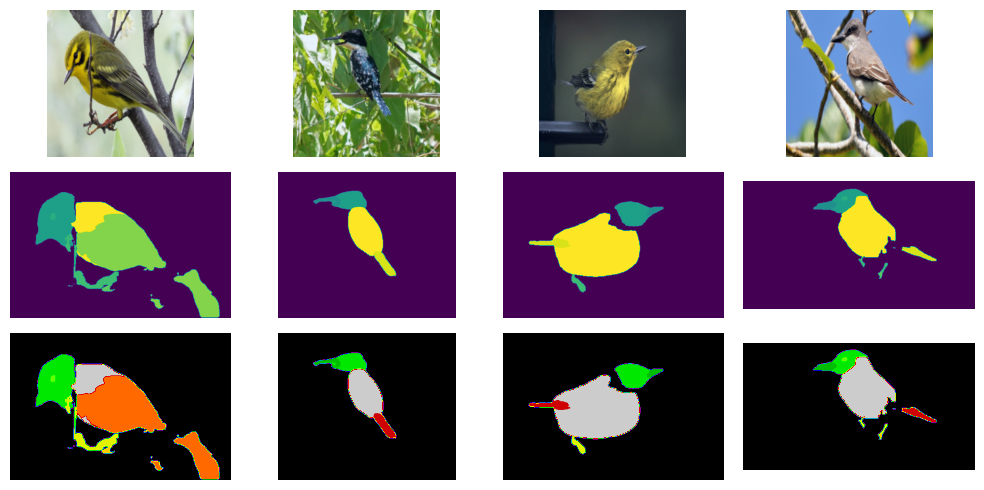

In [74]:
# fig, axs = plt.subplots(2, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

# for col_idx, (image_i, segments_i) in enumerate(zip(inputs, all_segments)):

#     axs[0, col_idx].imshow(imsc(image_i))
#     axs[0, col_idx].set_axis_off()

#     axs[1, col_idx].imshow(segments_i)
#     axs[1, col_idx].set_axis_off()

# fig.tight_layout()

fig, axs = plt.subplots(3, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

for col_idx, (image_i, segments_dict) in enumerate(zip(inputs, vlpart_final_segmentations)):

    axs[0, col_idx].imshow(imsc(image_i))
    axs[0, col_idx].set_axis_off()

    # convert segments_dict to a single 2D label array
    segments_img = np.zeros_like(next(iter(segments_dict.values())), dtype=np.int32)
    for class_id, mask in segments_dict.items():
        segments_img[mask.astype(bool)] = class_id

    
    axs[1, col_idx].imshow(segments_img)
    axs[1, col_idx].set_axis_off()
    
    axs[2, col_idx].imshow(segments_img, cmap='nipy_spectral')
    axs[2, col_idx].set_axis_off()

fig.tight_layout()
plt.show()


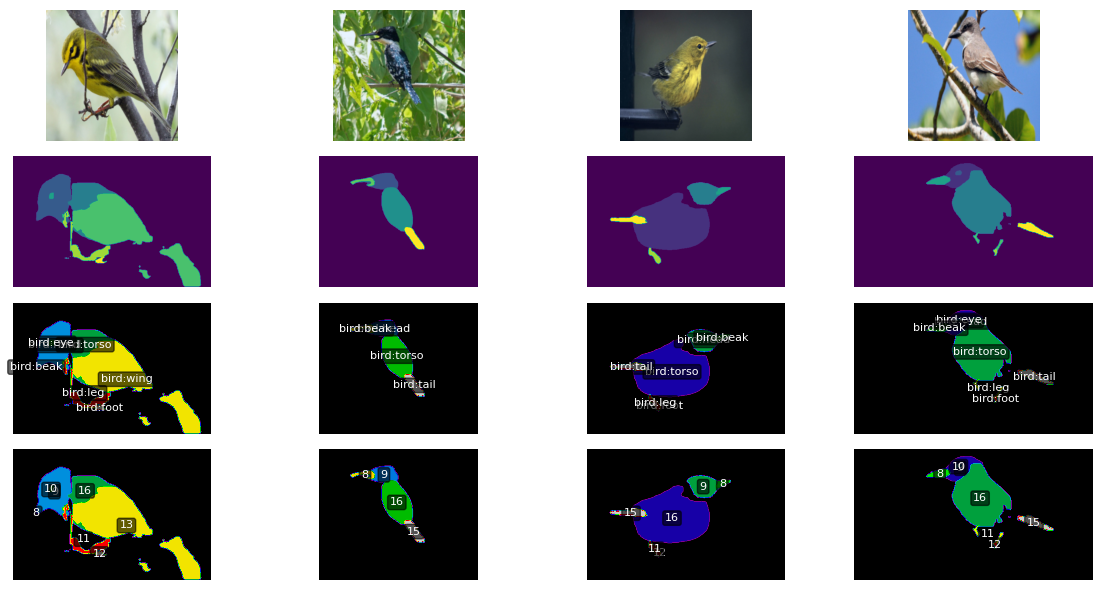

In [75]:
import matplotlib.pyplot as plt
from skimage.measure import regionprops
import numpy as np

fig, axs = plt.subplots(4, NUMBER_OF_PROTOTYPES + 2, figsize=(12, 6))

for col_idx, (image_i, mask_dict, segmentation_dict) in enumerate(zip(inputs, vlpart_final_masks, vlpart_final_segmentations)):

    # Row 0: original image
    axs[0, col_idx].imshow(imsc(image_i))
    axs[0, col_idx].set_axis_off()

    # Create a label map (single 2D array)
    label_map = np.zeros_like(next(iter(mask_dict.values())), dtype=np.int32)

    label_to_mask_name = {}       # 1: "bird:wing"
    label_to_segment_class = {}   # 1: 8 (class_id)

    for idx, (name, mask) in enumerate(mask_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_mask_name[idx] = name

    for idx, (class_id, mask) in enumerate(segmentation_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_segment_class[idx] = class_id

    # Row 1: plain integer mask
    axs[1, col_idx].imshow(label_map)
    axs[1, col_idx].set_axis_off()

    # Row 2: colored mask with text from mask_dict
    axs[2, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[2, col_idx].set_axis_off()

    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        label_text = label_to_mask_name.get(label, "unknown")

        axs[2, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

    # Row 3: colored mask with text from segmentation_dict (class IDs)
    axs[3, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[3, col_idx].set_axis_off()

    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        # print("label:", label)
        label_text = str(label_to_segment_class.get(label, "unknown"))

        axs[3, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

fig.tight_layout()
plt.show()



keypoint_i: 1
keypoint_i: 2
keypoint_i: 3
keypoint_i: 4
keypoint_i: 5
keypoint_i: 6
keypoint_i: 7
keypoint_i: 1
keypoint_i: 2
keypoint_i: 3
keypoint_i: 4
keypoint_i: 1
keypoint_i: 2
keypoint_i: 3
keypoint_i: 4
keypoint_i: 5
keypoint_i: 1
keypoint_i: 2
keypoint_i: 3
keypoint_i: 4
keypoint_i: 5
keypoint_i: 6
keypoint_i: 7


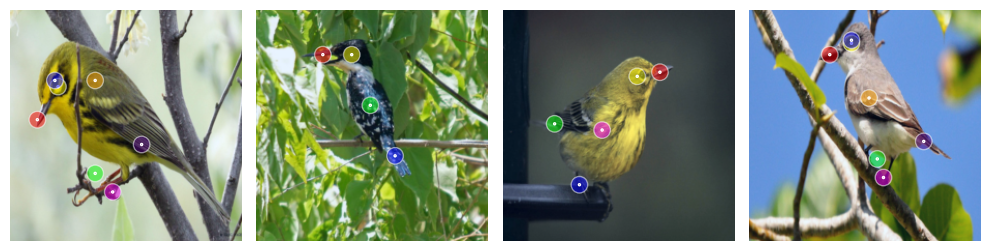

In [76]:
cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
                    "maroon", "black", "white", "chocolate", "gray", "blueviolet"])

fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

# all keypoints store the region ids, starting from 0
for col_idx, (image_i, keypoints_i) in enumerate(zip(inputs, all_keypoints)):

    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    # colors = np.array([cmap(x) for x in range(np.max(keypoints_i))]) # same as np.unique(keypoints_i) here, because all the keypoints are from 1 to n
    colors = np.array([cmap(x) for x in range(len(np.unique(keypoints_i)))])
    radius1, radius2 = 8, 1

    for keypoint_i, color in zip(np.unique(keypoints_i)[1:], colors):
        print("keypoint_i:", keypoint_i)
        y_coordinate, x_coordinate = np.where(keypoints_i==keypoint_i)

        circ1_1 = plt.Circle((x_coordinate, y_coordinate), radius1, facecolor=color, edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x_coordinate, y_coordinate), radius2, facecolor=color, edgecolor='white')
        axs[col_idx].add_patch(circ1_1)
        axs[col_idx].add_patch(circ1_2)

fig.tight_layout()

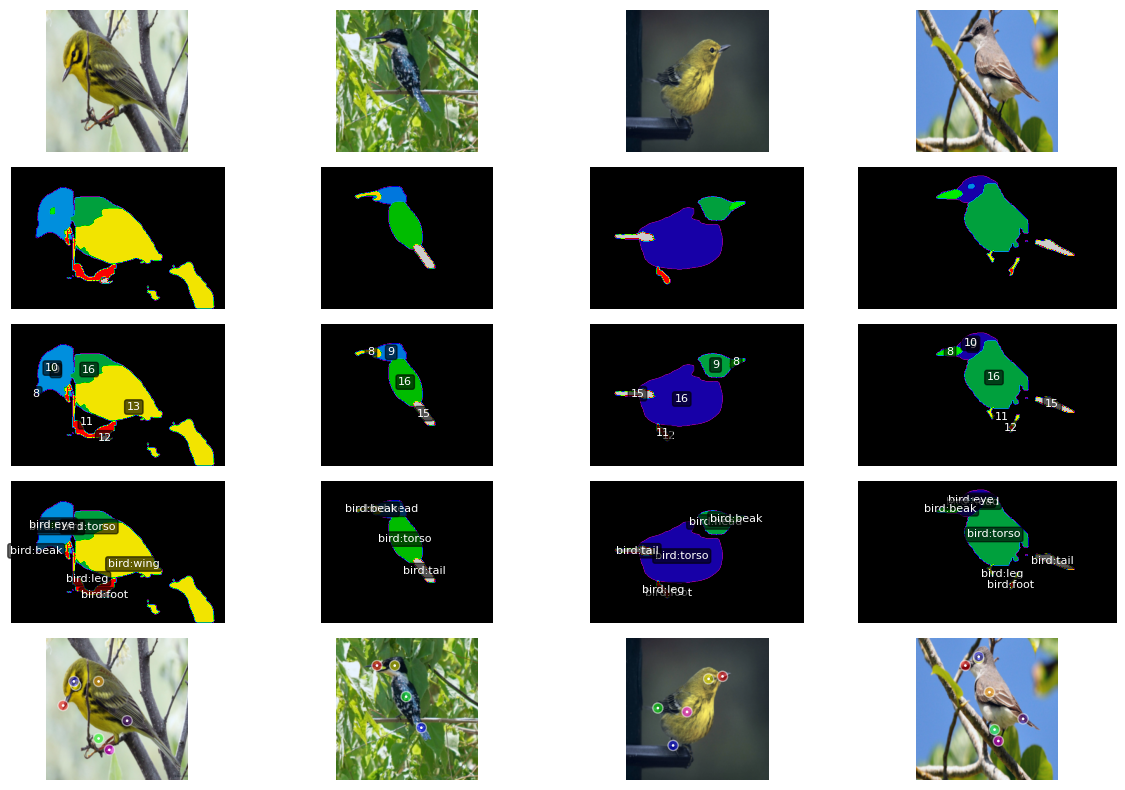

In [77]:
import matplotlib.pyplot as plt
from skimage.measure import regionprops
import numpy as np
from matplotlib.colors import ListedColormap

fig, axs = plt.subplots(5, NUMBER_OF_PROTOTYPES + 2, figsize=(12, 8)) 

cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet"
])

for col_idx, (image_i, mask_dict, segmentation_dict, keypoints_i) in enumerate(zip(inputs, vlpart_final_masks, vlpart_final_segmentations, all_keypoints)):

    # Row 0: original image
    axs[0, col_idx].imshow(imsc(image_i))
    axs[0, col_idx].set_axis_off()

    # Create label map
    label_map = np.zeros_like(next(iter(mask_dict.values())), dtype=np.int32)
    label_to_mask_name = {}
    label_to_segment_class = {}

    for idx, (name, mask) in enumerate(mask_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_mask_name[idx] = name

    for idx, (class_id, mask) in enumerate(segmentation_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_segment_class[idx] = class_id

    # Row 1: segmentation visualization
    axs[1, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[1, col_idx].set_axis_off()

    # Row 2: segmentation class ID (数字)
    axs[2, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[2, col_idx].set_axis_off()
    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        label_text = str(label_to_segment_class.get(label, "unknown"))
        axs[2, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

    # Row 3: segmentation name (文字)
    axs[3, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[3, col_idx].set_axis_off()
    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        label_text = label_to_mask_name.get(label, "unknown")
        axs[3, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

    # Row 4: keypoints
    axs[4, col_idx].imshow(imsc(image_i))
    axs[4, col_idx].set_axis_off()

    colors = np.array([cmap(x) for x in range(len(np.unique(keypoints_i)))])
    radius1, radius2 = 8, 1

    for keypoint_val, color in zip(np.unique(keypoints_i)[1:], colors):
        y, x = np.where(keypoints_i == keypoint_val)
        circ1 = plt.Circle((x[0], y[0]), radius1, facecolor=color, edgecolor='white', alpha=0.5)
        circ2 = plt.Circle((x[0], y[0]), radius2, facecolor=color, edgecolor='white')
        axs[4, col_idx].add_patch(circ1)
        axs[4, col_idx].add_patch(circ2)

fig.tight_layout()
plt.show()


In [78]:
# print(vlpart_final_segmentations)
for i in range(len(vlpart_final_segmentations)):
    # print(np.unique(vlpart_final_segmentations[i]))
    for id, mask in vlpart_final_segmentations[i].items():
        print("id:", id)
        print("mask shape:", mask.shape)
        print("mask unique values:", np.unique(mask))

id: 8
mask shape: (333, 500)
mask unique values: [0 1]
id: 9
mask shape: (333, 500)
mask unique values: [0 1]
id: 16
mask shape: (333, 500)
mask unique values: [0 1]
id: 10
mask shape: (333, 500)
mask unique values: [0 1]
id: 13
mask shape: (333, 500)
mask unique values: [0 1]
id: 11
mask shape: (333, 500)
mask unique values: [0 1]
id: 12
mask shape: (333, 500)
mask unique values: [0 1]
id: 9
mask shape: (414, 500)
mask unique values: [0 1]
id: 16
mask shape: (414, 500)
mask unique values: [0 1]
id: 8
mask shape: (414, 500)
mask unique values: [0 1]
id: 15
mask shape: (414, 500)
mask unique values: [0 1]
id: 16
mask shape: (333, 500)
mask unique values: [0 1]
id: 10
mask shape: (333, 500)
mask unique values: [0 1]
id: 9
mask shape: (333, 500)
mask unique values: [0 1]
id: 8
mask shape: (333, 500)
mask unique values: [0 1]
id: 12
mask shape: (333, 500)
mask unique values: [0 1]
id: 11
mask shape: (333, 500)
mask unique values: [0 1]
id: 15
mask shape: (333, 500)
mask unique values: [0 1

In [79]:
import numpy as np
from skimage.transform import resize
from scipy.ndimage import binary_dilation

def safe_resize_segment_map(original_segment_array, resize_size, dilation_iterations=1):
    original_shape = original_segment_array.shape

    dilated_array = np.zeros_like(original_segment_array)
    for label in np.unique(original_segment_array):
        if label == 0:
            continue  
        mask = (original_segment_array == label)
        dilated_mask = binary_dilation(mask, iterations=dilation_iterations)
        dilated_array[dilated_mask] = label

    resized_segment_array = resize(
        dilated_array,
        (resize_size, resize_size),
        order=0,
        preserve_range=True,
        anti_aliasing=False
    ).astype(np.int32)
    
    return resized_segment_array

def safe_resize_segment_map_v2(original_segment_array, resize_size):

    # Step 1: use nearest resize ( cv2）
    resized_segment_array = cv2.resize(
        original_segment_array.astype(np.uint8),
        (resize_size, resize_size),
        interpolation=cv2.INTER_NEAREST
    )

    # Step 2: check if any label is missing
    original_labels = np.unique(original_segment_array)
    resized_labels = np.unique(resized_segment_array)
    missing_labels = np.setdiff1d(original_labels, resized_labels)

    if len(missing_labels) > 0:
        # Step 3: find the missing labels, and insert into the center of the resized array
        scale_x = resize_size / original_segment_array.shape[1]
        scale_y = resize_size / original_segment_array.shape[0]

        for label in missing_labels:
            ys, xs = np.where(original_segment_array == label)
            if len(xs) == 0:
                continue
            x_center = int(np.mean(xs) * scale_x)
            y_center = int(np.mean(ys) * scale_y)
            x_center = np.clip(x_center, 0, resize_size - 1)
            y_center = np.clip(y_center, 0, resize_size - 1)

            resized_segment_array[y_center, x_center] = label

    return resized_segment_array

def safe_resize_with_expand_labels(original_segment_array, resize_size, expand_distance=1):
    """
    Resize a segmentation map using skimage's expand_labels to preserve label regions.
    
    Parameters:
    - original_segment_array: 2D np.array of ints (segmentation labels)
    - resize_size: int or (height, width), output size
    - expand_distance: int, expansion distance in pixels
    
    Returns:
    - resized_segment_array: np.array of shape (resize_size, resize_size) with resized segmentation
    """

    # Step 1: Expand labels without overlapping
    expanded = expand_labels(original_segment_array, distance=expand_distance)

    # Step 2: Resize with nearest neighbor interpolation (preserves label identity)
    if isinstance(resize_size, int):
        resize_shape = (resize_size, resize_size)
    else:
        resize_shape = resize_size

    resized = resize(
        expanded,
        output_shape=resize_shape,
        order=0,  # nearest-neighbor interpolation
        preserve_range=True,
        anti_aliasing=False
    ).astype(np.int32)

    return resized

In [80]:
from scipy.ndimage import binary_dilation
number_of_query_regions = 0
number_of_prototype_regions = []
region_means = []

resize_size = 64
final_segment_arrays = []
final_segment_resized_arrays = []
# e.g. vlpart_final_segmentations = [{8：mask, 9: mask}, {1：mask, 9: mask}, {2：mask, 3: mask},{6：mask, 8: mask}]
for sample_i, sample_i_segments_dict in enumerate(vlpart_final_segmentations):
    print("len of vlpart_final_segmentations:", len(vlpart_final_segmentations))
    # Step 1: convert segments_dict to labeled array (original size)
    segments_array = np.zeros_like(next(iter(sample_i_segments_dict.values())), dtype=np.int32)
    for label, mask in sample_i_segments_dict.items():
        segments_array[mask.astype(bool)] = label  
    
    print("segments_array shape:", segments_array.shape)
    print("segments_array unique values:", np.unique(segments_array))

    # segments_array_resized = resize(
    #     segments_array, 
    #     (resize_size, resize_size), order=0,
    # ) 
    
    segments_array_resized = safe_resize_segment_map(
        segments_array,
        resize_size,
        dilation_iterations=1
    )
    
    original_labels = set(np.unique(segments_array))
    resized_labels = set(np.unique(segments_array_resized))
    missing_labels = original_labels - resized_labels
    print("Missing labels after resize:", missing_labels)
    
    final_segment_arrays.append(segments_array)
    final_segment_resized_arrays.append(segments_array_resized)
    
    print("segments_array_resized unique values:", np.unique(segments_array_resized))
    sample_i_region_means = []

    # Step 3: embedding reshape and resize
    embeding = embedings[sample_i].reshape(NUMBER_OF_PATCHES_X, NUMBER_OF_PATCHES_Y, -1)
    embeding_resized = resize(
        embeding, 
        (resize_size, resize_size), 
        anti_aliasing=True, 
        preserve_range=False
    ).reshape(-1, LATENT_DIM)

    if sample_i == 0:
        # number_of_query_regions = np.max(segments_array_resized)
        number_of_query_regions = len(np.unique(segments_array_resized)) - 1 
    else:
        # number_of_prototype_regions.append(np.max(segments_array_resized))
        number_of_prototype_regions.append(len(np.unique(segments_array_resized)) - 1)
    print(np.max(segments_array_resized)-1)
    print(np.unique(segments_array_resized))

    # Step 4: Compute mean embeddings per segment
    for segment_i in np.unique(segments_array_resized):
        print("segment_i:", segment_i)
        if segment_i == 0:
            continue

        segment_i_indices = np.where(segments_array_resized.flatten() == segment_i)[0]

        if segment_i_indices.size == 0:
            continue

        segment_mean = np.mean(embeding_resized[segment_i_indices], axis=0)
        # print("segment_mean :", segment_mean)
        sample_i_region_means.append(segment_mean)

    # print("sample_i_region_means:", sample_i_region_means)
    region_means.append(sample_i_region_means)


len of vlpart_final_segmentations: 4
segments_array shape: (333, 500)
segments_array unique values: [ 0  8  9 10 11 12 13 16]
Missing labels after resize: set()
segments_array_resized unique values: [ 0  8  9 10 11 12 13 16]
15
[ 0  8  9 10 11 12 13 16]
segment_i: 0
segment_i: 8
segment_i: 9
segment_i: 10
segment_i: 11
segment_i: 12
segment_i: 13
segment_i: 16
len of vlpart_final_segmentations: 4
segments_array shape: (414, 500)
segments_array unique values: [ 0  8  9 15 16]
Missing labels after resize: set()
segments_array_resized unique values: [ 0  8  9 15 16]
15
[ 0  8  9 15 16]
segment_i: 0
segment_i: 8
segment_i: 9
segment_i: 15
segment_i: 16
len of vlpart_final_segmentations: 4
segments_array shape: (333, 500)
segments_array unique values: [ 0  8  9 11 12 15 16]
Missing labels after resize: {12}
segments_array_resized unique values: [ 0  8  9 11 15 16]
15
[ 0  8  9 11 15 16]
segment_i: 0
segment_i: 8
segment_i: 9
segment_i: 11
segment_i: 15
segment_i: 16
len of vlpart_final_segm

In [81]:

query_region_means = np.array(region_means[0])

prototype_region_means = np.concatenate(region_means[1:])

nearest_neighbor_query, distances_query = pairwise_distances_argmin_min(query_region_means, prototype_region_means, axis=1, metric='cosine')
nearest_neighbor_prototypes, distances_prototype = pairwise_distances_argmin_min(query_region_means, prototype_region_means, axis=0, metric='cosine')

print("nearest_neighbor_query:", nearest_neighbor_query)
print("nearest_neighbor_prototypes:", nearest_neighbor_prototypes)

print("arange query regions:", np.arange(number_of_query_regions))
print("arange prototype all regions:", np.arange(np.sum(number_of_prototype_regions)))

best_buddies_query = nearest_neighbor_prototypes[nearest_neighbor_query] == np.arange(number_of_query_regions)
best_buddies_prototypes = nearest_neighbor_query[nearest_neighbor_prototypes] == np.arange(np.sum(number_of_prototype_regions))

best_buddies_query_indices = nearest_neighbor_query[best_buddies_query]
best_buddies_prototypes_indices = nearest_neighbor_prototypes[best_buddies_prototypes]

print("best buddies query:", best_buddies_query)
print("best buddies prototypes:", best_buddies_prototypes)

best_buddies_query_indices = np.where(nearest_neighbor_prototypes[nearest_neighbor_query] == np.arange(number_of_query_regions))[0]
best_buddies_prototypes_indices = np.where(nearest_neighbor_query[nearest_neighbor_prototypes] == np.arange(np.sum(number_of_prototype_regions)))[0]

print("best_buddies_query_indices:", best_buddies_query_indices)
print("best_buddies_prototypes_indices:", best_buddies_prototypes_indices)



nearest_neighbor_query: [ 4  5  5 12  6  8  8]
nearest_neighbor_prototypes: [0 1 5 6 0 1 4 5 6 0 1 1 4 4 5 5]
arange query regions: [0 1 2 3 4 5 6]
arange prototype all regions: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
best buddies query: [ True  True False False  True False  True]
best buddies prototypes: [False False False False  True  True  True False  True False False False
 False False False False]
best_buddies_query_indices: [0 1 4 6]
best_buddies_prototypes_indices: [4 5 6 8]


In [82]:
print(best_buddies_query_indices)
print(np.nonzero(best_buddies_query)[0])
print(np.arange(number_of_query_regions)[np.nonzero(best_buddies_query)[0]])
#np.arange(number_of_query_regions)[np.nonzero(best_buddies_query)[0]]

print(np.nonzero(best_buddies_prototypes)[0])
print(np.arange(np.sum(number_of_prototype_regions))[np.nonzero(best_buddies_prototypes)[0]])

[0 1 4 6]
[0 1 4 6]
[0 1 4 6]
[4 5 6 8]
[4 5 6 8]


In [83]:
print("len of query_region",number_of_query_regions)
print("len of prototype_region",number_of_prototype_regions)
# print("final segments array:", final_segment_arrays)
def rebuild_best_buddies_prototype_indices(prototype_indices,num_prototype,segments_array):
    unique_segments = []
    num_prototypes = 0
    for i, segments in enumerate(segments_array):
        unique_segments.append(np.unique(segments))
        print("len of unique segments per image:", len(unique_segments[i]))
    # print("unique_segments:", unique_segments)
    # print("prototype_indices:", prototype_indices)
        if i != 0:
            num_prototypes += len(unique_segments[i])
    print("number of prototypes", num_prototypes)
    return prototype_indices
rebuild_best_buddies_prototype_indices(best_buddies_prototypes_indices,number_of_prototype_regions,final_segment_arrays)
rebuild_best_buddies_prototype_indices(best_buddies_prototypes_indices,number_of_prototype_regions,final_segment_resized_arrays)

len of query_region 7
len of prototype_region [4, 5, 7]
len of unique segments per image: 8
len of unique segments per image: 5
len of unique segments per image: 7
len of unique segments per image: 8
number of prototypes 20
len of unique segments per image: 8
len of unique segments per image: 5
len of unique segments per image: 6
len of unique segments per image: 8
number of prototypes 19


array([4, 5, 6, 8])

all keypoints: [array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32), array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32), array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32), array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)]


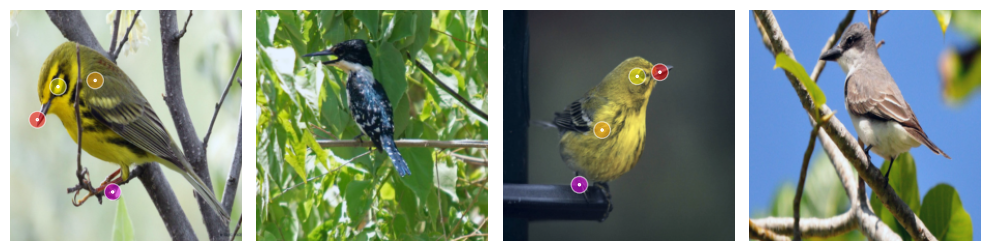

In [84]:
# cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
#                     "maroon", "black", "white", "chocolate", "gray", "blueviolet"])
cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
])

# colors = np.array([cmap(x) for x in range(15)])
colors = np.array([cmap(x) for x in range(cmap.N)])

mnn_matches = {}

print("all keypoints:", all_keypoints)
fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

for col_idx, (image_i, keypoints_i) in enumerate(zip(inputs, all_keypoints)):

    #print('Sample', col_idx)
    #print(50*'-')

    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):

        if col_idx == 0:
          if not best_buddies_query[keypoint_i-1]: continue
        elif col_idx == 1:
          if not best_buddies_prototypes[keypoint_i-1]: continue
        else:
          if not best_buddies_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]: continue
          # offset = np.sum(number_of_prototype_regions[:(col_idx - 1)])
          # global_id = offset + keypoint_i - 1
          
          # print(f"col_idx={col_idx}, keypoint_i={keypoint_i}, offset={offset}, global_id={global_id}")
          # print("included in best buddies?", best_buddies_prototypes[global_id])

          # if not best_buddies_prototypes[global_id]: continue

        if col_idx == 0:
          color_value = keypoint_counter
          mnn_matches[keypoint_i-1] = color_value
        elif col_idx == 1:
          color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i-1]]
        else:
          color_value = mnn_matches[nearest_neighbor_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]]

        
        y_coordinate, x_coordinate = np.where(keypoints_i==keypoint_i)

        circ1_1 = plt.Circle((x_coordinate, y_coordinate), radius1, facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x_coordinate, y_coordinate), radius2, facecolor=colors[color_value], edgecolor='white')
  
        axs[col_idx].add_patch(circ1_1)
        axs[col_idx].add_patch(circ1_2)


fig.tight_layout()



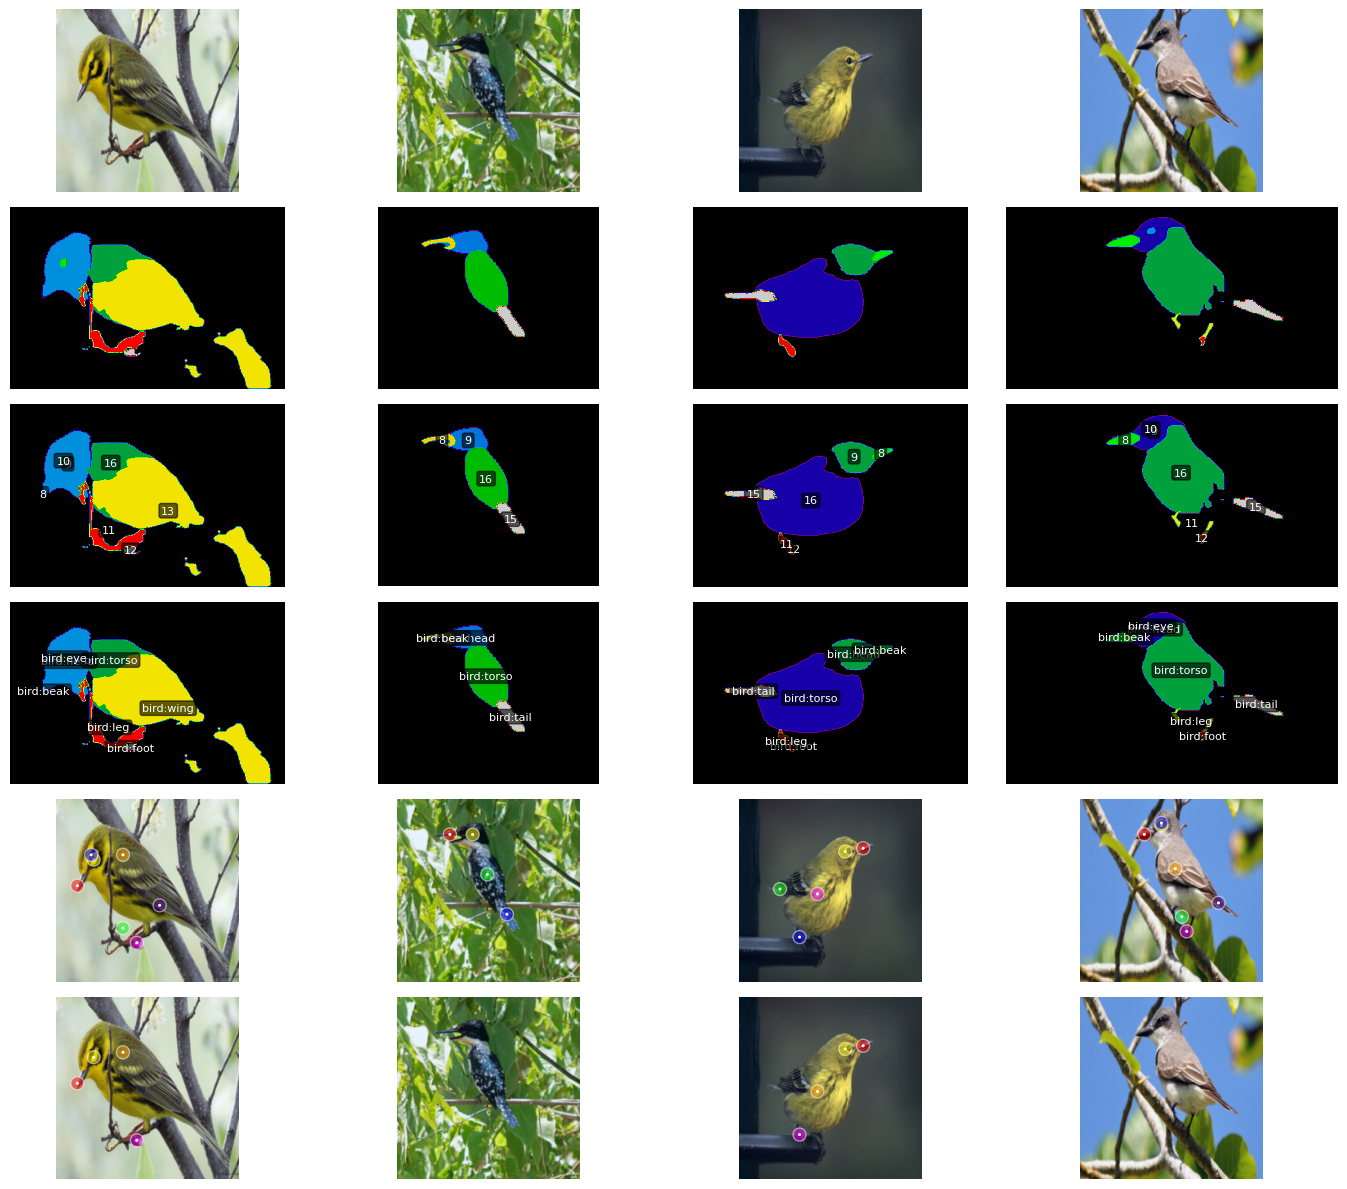

In [85]:
import matplotlib.pyplot as plt
from skimage.measure import regionprops
import numpy as np
from matplotlib.colors import ListedColormap

# === initialize colormap ===
cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
])
colors = np.array([cmap(x) for x in range(cmap.N)])


fig, axs = plt.subplots(6, NUMBER_OF_PROTOTYPES + 2, figsize=(14, 12))
mnn_matches = {}


for col_idx, (image_i, mask_dict, segmentation_dict, keypoints_i) in enumerate(zip(inputs, vlpart_final_masks, vlpart_final_segmentations, all_keypoints)):

    # Row 0: raw image
    axs[0, col_idx].imshow(imsc(image_i))
    axs[0, col_idx].set_axis_off()

    # === label_map & label_to_mask_name ===
    label_map = np.zeros_like(next(iter(mask_dict.values())), dtype=np.int32)
    label_to_mask_name = {}
    label_to_segment_class = {}

    for idx, (name, mask) in enumerate(mask_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_mask_name[idx] = name

    for idx, (class_id, mask) in enumerate(segmentation_dict.items(), start=1):
        label_map[mask.astype(bool)] = idx
        label_to_segment_class[idx] = class_id

    # Row 1: segmentation mask
    axs[1, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[1, col_idx].set_axis_off()

    # Row 2: class ID
    axs[2, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[2, col_idx].set_axis_off()
    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        label_text = str(label_to_segment_class.get(label, "unknown"))
        axs[2, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

    # Row 3: class name
    axs[3, col_idx].imshow(label_map, cmap='nipy_spectral')
    axs[3, col_idx].set_axis_off()
    for prop in regionprops(label_map):
        y, x = prop.centroid
        label = prop.label
        label_text = label_to_mask_name.get(label, "unknown")
        axs[3, col_idx].text(x, y, label_text, fontsize=8, color='white',
                             ha='center', va='center',
                             bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2'))

    # Row 4: all keypoints
    axs[4, col_idx].imshow(imsc(image_i))
    axs[4, col_idx].set_axis_off()
    for idx, keypoint_val in enumerate(np.unique(keypoints_i)[1:]):
        y, x = np.where(keypoints_i == keypoint_val)
        if len(x) == 0 or len(y) == 0:
            continue
        x, y = x[0], y[0]
        circ1 = plt.Circle((x, y), 8, facecolor=colors[idx], edgecolor='white', alpha=0.5)
        circ2 = plt.Circle((x, y), 1, facecolor=colors[idx], edgecolor='white')
        axs[4, col_idx].add_patch(circ1)
        axs[4, col_idx].add_patch(circ2)

    # Row 5: best buddies
    axs[5, col_idx].imshow(imsc(image_i))
    axs[5, col_idx].set_axis_off()
    radius1, radius2 = 8, 1

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):
        if col_idx == 0:
            if not best_buddies_query[keypoint_i - 1]:
                continue
        elif col_idx == 1:
            if not best_buddies_prototypes[keypoint_i - 1]:
                continue
        else:
            offset = np.sum(number_of_prototype_regions[:(col_idx - 1)])
            global_id = offset + keypoint_i - 1
            if not best_buddies_prototypes[global_id]:
                continue

        # Assign color value based on the column index
        if col_idx == 0:
            color_value = keypoint_counter
            mnn_matches[keypoint_i - 1] = color_value
        elif col_idx == 1:
            color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i - 1]]
        else:
            global_id = np.sum(number_of_prototype_regions[:(col_idx - 1)]) + keypoint_i - 1
            color_value = mnn_matches[nearest_neighbor_prototypes[global_id]]

        y, x = np.where(keypoints_i == keypoint_i)
        if len(x) == 0 or len(y) == 0:
            continue
        x, y = x[0], y[0]

        circ1 = plt.Circle((x, y), radius1, facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        circ2 = plt.Circle((x, y), radius2, facecolor=colors[color_value], edgecolor='white')
        axs[5, col_idx].add_patch(circ1)
        axs[5, col_idx].add_patch(circ2)

fig.tight_layout()
plt.show()


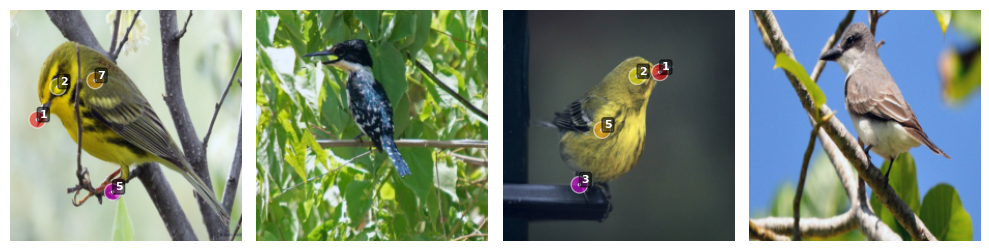

In [86]:
# cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
#                     "maroon", "black", "white", "chocolate", "gray", "blueviolet"])
cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
])

# colors = np.array([cmap(x) for x in range(15)])
colors = np.array([cmap(x) for x in range(cmap.N)])

mnn_matches = {}

# print("all keypoints:", all_keypoints)
fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

for col_idx, (image_i, keypoints_i) in enumerate(zip(inputs, all_keypoints)):

    #print('Sample', col_idx)
    #print(50*'-')

    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):

        if col_idx == 0:
          if not best_buddies_query[keypoint_i-1]: continue
        elif col_idx == 1:
          if not best_buddies_prototypes[keypoint_i-1]: continue
        else:
          if not best_buddies_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]: continue

        if col_idx == 0:
          color_value = keypoint_counter
          mnn_matches[keypoint_i-1] = color_value
        elif col_idx == 1:
          color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i-1]]
        else:
          color_value = mnn_matches[nearest_neighbor_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]]

        y_coordinate, x_coordinate = np.where(keypoints_i==keypoint_i)

        circ1_1 = plt.Circle((x_coordinate, y_coordinate), radius1, facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x_coordinate, y_coordinate), radius2, facecolor=colors[color_value], edgecolor='white')
  
        axs[col_idx].add_patch(circ1_1)
        axs[col_idx].add_patch(circ1_2)

        # add label
        axs[col_idx].text(
            x_coordinate + 2, y_coordinate - 2,
            str(keypoint_i),
            fontsize=8,
            color='white',
            weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
        )
fig.tight_layout()



image_masks_i: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
keypoint_i: 1
label_list: [ 0  8  9 10 11 12 13 16]
label: 8
keypoint_i: 2
label_list: [ 0  8  9 10 11 12 13 16]
label: 9
keypoint_i: 5
label_list: [ 0  8  9 10 11 12 13 16]
label: 12
keypoint_i: 7
label_list: [ 0  8  9 10 11 12 13 16]
label: 16
image_masks_i: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
image_masks_i: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
keypoint_i: 1
label_list: [ 0  8  9 11 12 15 16]
label: 8
keypoint_i: 2
label_list: [ 0  8  9 11 12 15 16]
label: 9
keypoint_i: 3
label_list: [ 0  8  9 11 12 15 16]
label: 11
keypoint_i: 5
label_list: [ 0  8  9 11 12 15 16]
label: 15
image_masks_i: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]


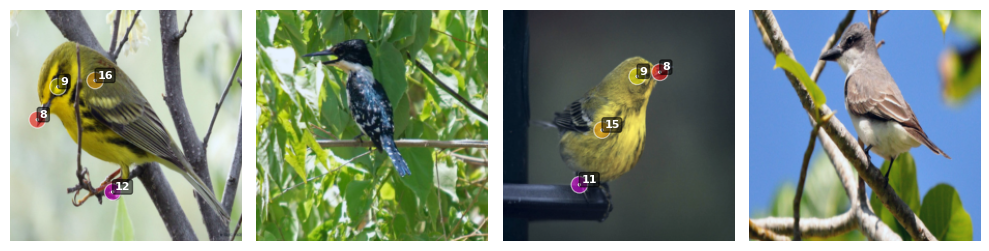

In [87]:
# cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
#                     "maroon", "black", "white", "chocolate", "gray", "blueviolet"])
cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
])

# colors = np.array([cmap(x) for x in range(15)])
colors = np.array([cmap(x) for x in range(cmap.N)])

mnn_matches = {}

# print("all keypoints:", all_keypoints)
fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

for col_idx, (image_i, keypoints_i, image_segment_i) in enumerate(zip(inputs, all_keypoints, final_segment_arrays)):

    #print('Sample', col_idx)
    #print(50*'-')
    print("image_masks_i:", image_segment_i)
    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):

        if col_idx == 0:
          if not best_buddies_query[keypoint_i-1]: continue
        elif col_idx == 1:
          if not best_buddies_prototypes[keypoint_i-1]: continue
        else:
          if not best_buddies_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]: continue

        if col_idx == 0:
          color_value = keypoint_counter
          mnn_matches[keypoint_i-1] = color_value
        elif col_idx == 1:
          color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i-1]]
        else:
          color_value = mnn_matches[nearest_neighbor_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]]

      
        y_coordinate, x_coordinate = np.where(keypoints_i==keypoint_i)

        circ1_1 = plt.Circle((x_coordinate, y_coordinate), radius1, facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x_coordinate, y_coordinate), radius2, facecolor=colors[color_value], edgecolor='white')
  
        axs[col_idx].add_patch(circ1_1)
        axs[col_idx].add_patch(circ1_2)

        print("keypoint_i:", keypoint_i)
        label_list = np.unique(image_segment_i)
        print("label_list:", label_list)
        label = label_list[keypoint_i]
        print("label:", label)

        axs[col_idx].text(
            x_coordinate + 2, y_coordinate - 2,
            label,
            fontsize=8,
            color='white',
            weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
        )
fig.tight_layout()



keypoint_i: 1
label_list: [ 0  8  9 10 11 12 13 16]
label: 8
keypoint_i: 2
label_list: [ 0  8  9 10 11 12 13 16]
label: 9
keypoint_i: 5
label_list: [ 0  8  9 10 11 12 13 16]
label: 12
keypoint_i: 7
label_list: [ 0  8  9 10 11 12 13 16]
label: 16
keypoint_i: 1
label_list: [ 0  8  9 11 15 16]
label: 8
keypoint_i: 2
label_list: [ 0  8  9 11 15 16]
label: 9
keypoint_i: 3
label_list: [ 0  8  9 11 15 16]
label: 11
keypoint_i: 5
label_list: [ 0  8  9 11 15 16]
label: 16


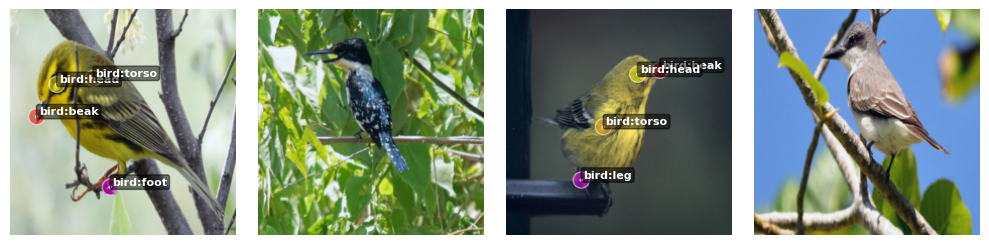

In [88]:
        
# cmap = ListedColormap(["red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
#                     "maroon", "black", "white", "chocolate", "gray", "blueviolet"])
cmap = ListedColormap([
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
])

# colors = np.array([cmap(x) for x in range(15)])
colors = np.array([cmap(x) for x in range(cmap.N)])

mnn_matches = {}

# print("all keypoints:", all_keypoints)
fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES+2, figsize=(10, 5))

for col_idx, (image_i, keypoints_i, image_segment_array_i ) in enumerate(zip(inputs, all_keypoints, final_segment_resized_arrays)):

    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1
        
    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):

        if col_idx == 0:
          if not best_buddies_query[keypoint_i-1]: continue
        elif col_idx == 1:
          if not best_buddies_prototypes[keypoint_i-1]: continue
        else:
          if not best_buddies_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]: continue

        if col_idx == 0:
          color_value = keypoint_counter
          mnn_matches[keypoint_i-1] = color_value
        elif col_idx == 1:
          color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i-1]]
        else:
          color_value = mnn_matches[nearest_neighbor_prototypes[np.sum(number_of_prototype_regions[:(col_idx-1)])+keypoint_i-1]]

      
        y_coordinate, x_coordinate = np.where(keypoints_i==keypoint_i)

        circ1_1 = plt.Circle((x_coordinate, y_coordinate), radius1, facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        circ1_2 = plt.Circle((x_coordinate, y_coordinate), radius2, facecolor=colors[color_value], edgecolor='white')
  
        axs[col_idx].add_patch(circ1_1)
        axs[col_idx].add_patch(circ1_2)

        print("keypoint_i:", keypoint_i)
        label_list = np.unique(image_segment_array_i)
        print("label_list:", label_list)
        label = label_list[keypoint_i]
        print("label:", label)
        label_text = get_class_dict("pascal_part_val").get(label, "unknown")

        axs[col_idx].text(
            x_coordinate + 2, y_coordinate - 2,
            label_text,
            fontsize=8,
            color='white',
            weight='bold',
            bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
        )
        
fig.tight_layout()



/tmp/ipykernel_309628/1186257574.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


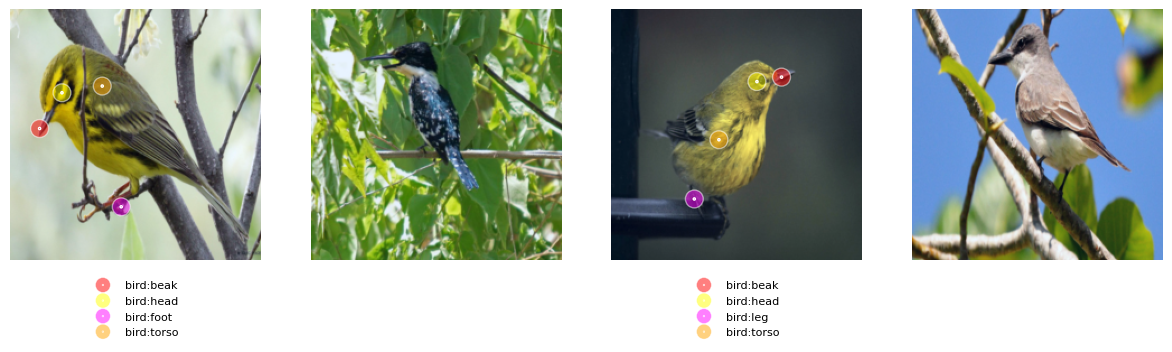

In [89]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerPatch


color_names = [
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
]
cmap = ListedColormap(color_names)
colors = np.array([cmap(i) for i in range(cmap.N)])


class DoubleCircleHandler(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = (xdescent + width / 2, ydescent + height / 2)
        outer = Circle(center, width / 3, facecolor=orig_handle.get_facecolor(), alpha=0.5, edgecolor='white', lw=0.5)
        inner = Circle(center, width / 30, facecolor=orig_handle.get_facecolor(), edgecolor='white', lw=0.5)
        return [outer, inner]


def make_double_circle_legend(ax, color_label_dict):
    handles = []
    labels = []
    used_colors = set()
    for color_id, tags in color_label_dict.items():
        if tags and color_id not in used_colors:
            label_str = ", ".join(sorted(set(tags)))
            # color_name = color_names[color_id]
            circle = Circle((0, 0), 1, facecolor=colors[color_id])
            handles.append(circle)
            labels.append(f"{label_str}")
            used_colors.add(color_id)

    ax.legend(
        handles=handles,
        labels=labels,
        handler_map={Circle: DoubleCircleHandler()},
        loc='lower center',
        bbox_to_anchor=(0.5, -0.35),  
        fontsize=8,
        frameon=False,
        ncol=1,
        handletextpad=1.0,
        borderpad=0.4
    )


fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES + 2, figsize=(12, 6))
fig.subplots_adjust(bottom=0.4, top=0.95, left=0.02, right=0.98, wspace=0.2)

mnn_matches = {}

for col_idx, (image_i, keypoints_i, image_segment_array_i) in enumerate(zip(inputs, all_keypoints, final_segment_resized_arrays)):
    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1
    color_label_dict = {i: [] for i in range(cmap.N)}

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):

        if col_idx == 0:
            if not best_buddies_query[keypoint_i - 1]: continue
        elif col_idx == 1:
            if not best_buddies_prototypes[keypoint_i - 1]: continue
        else:
            offset = np.sum(number_of_prototype_regions[:(col_idx - 1)])
            if not best_buddies_prototypes[offset + keypoint_i - 1]: continue

        if col_idx == 0:
            color_value = keypoint_counter
            mnn_matches[keypoint_i - 1] = color_value
        elif col_idx == 1:
            color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i - 1]]
        else:
            color_value = mnn_matches[nearest_neighbor_prototypes[offset + keypoint_i - 1]]

        y_coordinate, x_coordinate = np.where(keypoints_i == keypoint_i)

        axs[col_idx].add_patch(
            plt.Circle((x_coordinate, y_coordinate), radius1,
                       facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        )
        axs[col_idx].add_patch(
            plt.Circle((x_coordinate, y_coordinate), radius2,
                       facecolor=colors[color_value], edgecolor='white')
        )

        label_list = np.unique(image_segment_array_i)
        label = label_list[keypoint_i]
        label_text = get_class_dict("pascal_part_val").get(label, "unknown")
        color_label_dict[color_value].append(label_text)

    make_double_circle_legend(axs[col_idx], color_label_dict)

plt.show()


/tmp/ipykernel_309628/3621138125.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


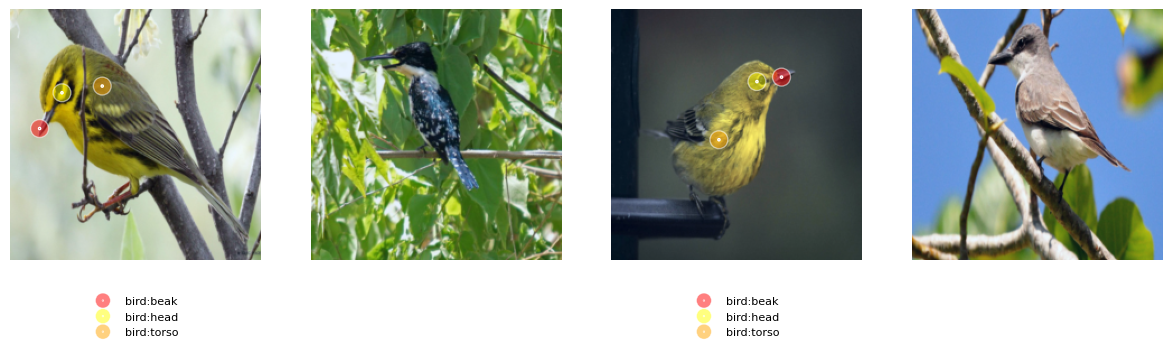

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle
from matplotlib.legend_handler import HandlerPatch

color_names = [
    "red", "yellow", "blue", "lime", "magenta", "indigo", "orange", "cyan", "darkgreen",
    "maroon", "black", "white", "chocolate", "gray", "blueviolet",
    "olive", "teal", "navy", "coral", "plum", "pink", "gold", "brown", "turquoise", "orchid"
]
cmap = ListedColormap(color_names)
colors = np.array([cmap(i) for i in range(cmap.N)])

class DoubleCircleHandler(HandlerPatch):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        center = (xdescent + width / 2, ydescent + height / 2)
        outer = Circle(center, width / 3, facecolor=orig_handle.get_facecolor(), alpha=0.5, edgecolor='white', lw=0.5)
        inner = Circle(center, width / 30, facecolor=orig_handle.get_facecolor(), edgecolor='white', lw=0.5)
        return [outer, inner]

def make_double_circle_legend(ax, color_label_dict):
    handles = []
    labels = []
    used_colors = set()
    for color_id, tags in color_label_dict.items():
        if tags and color_id not in used_colors:
            label_str = ", ".join(sorted(set(tags)))
            circle = Circle((0, 0), 1, facecolor=colors[color_id])
            handles.append(circle)
            labels.append(f"{label_str}")
            used_colors.add(color_id)

    ax.legend(
        handles=handles,
        labels=labels,
        handler_map={Circle: DoubleCircleHandler()},
        loc='lower center',
        bbox_to_anchor=(0.5, -0.35),
        fontsize=8,
        frameon=False,
        ncol=1,
        handletextpad=1.0,
        borderpad=0.4
    )

fig, axs = plt.subplots(1, NUMBER_OF_PROTOTYPES + 2, figsize=(12, 6))
fig.subplots_adjust(bottom=0.4, top=0.95, left=0.02, right=0.98, wspace=0.2)

mnn_matches = {}

for col_idx, (image_i, keypoints_i, image_segment_array_i) in enumerate(zip(inputs, all_keypoints, final_segment_resized_arrays)):
    axs[col_idx].imshow(imsc(image_i))
    axs[col_idx].set_axis_off()

    radius1, radius2 = 8, 1
    color_label_dict = {i: [] for i in range(cmap.N)}

    for keypoint_counter, keypoint_i in enumerate(np.unique(keypoints_i)[1:]):
        if col_idx == 0:
            if not best_buddies_query[keypoint_i - 1]:
                continue
            # get current keypoint's label from query 
            label = np.unique(image_segment_array_i)[keypoint_i]
            label_text = get_class_dict("pascal_part_val").get(label, "unknown")

            # Find all prototype keypoints that match this query keypoint
            matched_proto_indices = [i for i, v in enumerate(nearest_neighbor_prototypes) if v == keypoint_i - 1 and best_buddies_prototypes[i]]

            # Check whether any prototype is consistent with query's semantics
            semantic_match = False
            for proto_i in matched_proto_indices:
                # Get the region number where prototype is located
                if proto_i < number_of_prototype_regions[0]:
                    proto_col = 1
                    offset = 0
                else:
                    for idx in range(1, len(number_of_prototype_regions)):
                        if proto_i < sum(number_of_prototype_regions[:idx + 1]):
                            proto_col = idx + 1
                            offset = sum(number_of_prototype_regions[:idx])
                            break

                proto_seg = final_segment_resized_arrays[proto_col]
                proto_keypoint_idx = proto_i - offset + 1
                proto_label = np.unique(proto_seg)[proto_keypoint_idx]
                proto_label_text = get_class_dict("pascal_part_val").get(proto_label, "unknown")

                if proto_label_text == label_text:
                    semantic_match = True
                    break

            if not semantic_match:
                continue

        elif col_idx == 1:
            if not best_buddies_prototypes[keypoint_i - 1]:
                continue
        else:
            offset = np.sum(number_of_prototype_regions[:(col_idx - 1)])
            if not best_buddies_prototypes[offset + keypoint_i - 1]:
                continue

        # Get current label for this keypoint
        label = np.unique(image_segment_array_i)[keypoint_i]
        label_text = get_class_dict("pascal_part_val").get(label, "unknown")

        # For col_idx > 0, perform semantic match check
        if col_idx > 0:
            if col_idx == 1:
                matched_query_idx = nearest_neighbor_prototypes[keypoint_i - 1]
            else:
                matched_query_idx = nearest_neighbor_prototypes[offset + keypoint_i - 1]

            query_seg = final_segment_resized_arrays[0]
            query_label = np.unique(query_seg)[matched_query_idx + 1]
            query_label_text = get_class_dict("pascal_part_val").get(query_label, "unknown")

            if query_label_text != label_text:
                continue  # skip mismatched semantic labels

        if col_idx == 0:
            color_value = keypoint_counter
            mnn_matches[keypoint_i - 1] = color_value
        elif col_idx == 1:
            color_value = mnn_matches[nearest_neighbor_prototypes[keypoint_i - 1]]
        else:
            color_value = mnn_matches[nearest_neighbor_prototypes[offset + keypoint_i - 1]]

        y_coordinate, x_coordinate = np.where(keypoints_i == keypoint_i)

        axs[col_idx].add_patch(
            plt.Circle((x_coordinate, y_coordinate), radius1,
                       facecolor=colors[color_value], edgecolor='white', alpha=0.5)
        )
        axs[col_idx].add_patch(
            plt.Circle((x_coordinate, y_coordinate), radius2,
                       facecolor=colors[color_value], edgecolor='white')
        )

        color_label_dict[color_value].append(label_text)

    make_double_circle_legend(axs[col_idx], color_label_dict)

plt.show()
